In [ ]:
# this code uses balanced_dataset.csv
# I adapted Audrey’s MoE pipeline by reusing her data loading and preprocessing steps, including reading from balanced_dataset.csv, dropping missing labels, selecting numerical features,
# filling missing values with zero, and applying her one-hot encoding function. I followed her use of StandardScaler (fit on training only), 80/20 train-test split, and 5-fold cross-validation.
# I then implemented a decision tree model with max_features='sqrt', min_samples_split=2, and no depth limit to examine overfitting. I added logic to evaluate metrics per fold, save them as .npy files,
# and report final test performance.



In [5]:
from google.colab import files
uploaded = files.upload()  # Upload zip file

Saving balanced_dataset.csv to balanced_dataset.csv


In [6]:
# -*- coding: utf-8 -*-

"""
Decision Tree Classification Pipeline

This script trains and evaluates a Decision Tree classifier using:

1. A locally uploaded balanced_dataset.csv file
2. An independent 20% test set
3. Five-fold stratified cross-validation on the remaining 80%
4. Accuracy, precision, recall, and F1-score
5. Final retraining on the complete training/validation partition
6. Independent test-set evaluation
7. Feature-importance analysis

The independent test set remains excluded from cross-validation and
final model fitting until the final evaluation step.
"""

# Import libraries

import argparse
import os
import time

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)

from sklearn.tree import DecisionTreeClassifier


# Command-line arguments and file paths

parser = argparse.ArgumentParser(
    description="Train and evaluate a Decision Tree classifier."
)

parser.add_argument(
    "--input",
    type=str,
    default="/content/balanced_dataset.csv",
    help=(
        "Path to balanced_dataset.csv. The default path assumes "
        "the file was uploaded to the local Colab runtime."
    )
)

parser.add_argument(
    "--output_dir",
    type=str,
    default="/content/drive/MyDrive/riboMoE_outputs/decision_tree",
    help=(
        "Google Drive directory used to save models, metrics, "
        "predictions, and feature-importance results."
    )
)

parser.add_argument(
    "--save_model",
    type=str,
    default="decision_tree_final.joblib",
    help="Filename used to save the final Decision Tree model."
)

# parse_known_args allows this code to run inside a Colab notebook,
# where additional notebook arguments may be present.
args, unknown = parser.parse_known_args()

INPUT_PATH = args.input
OUTPUT_DIR = args.output_dir

if not os.path.isfile(INPUT_PATH):
    raise FileNotFoundError(
        f"Could not find the dataset at:\n{INPUT_PATH}\n\n"
        "Upload balanced_dataset.csv to the local Colab runtime "
        "before running this code."
    )

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(f"Input dataset: {INPUT_PATH}")
print(f"Output directory: {OUTPUT_DIR}")


# Reproducibility settings

RANDOM_SEED = 42

np.random.seed(
    RANDOM_SEED
)


# Load dataset

print("\nLoading dataset...")

df = pd.read_csv(
    INPUT_PATH
)

required_columns = [
    "label",
    "complex_nucelotides"
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        "The following required columns are missing: "
        + ", ".join(missing_required_columns)
    )

# Remove observations without a valid label.
df = df.dropna(
    subset=["label"]
).copy()

print("\n===== Dataset Summary =====")
print(f"Number of observations: {df.shape[0]}")
print(f"Number of original columns: {df.shape[1]}")

print("\nLabel counts:")
print(
    df["label"].value_counts(
        dropna=False
    )
)

print("\nUnique label values:")
print(
    df["label"].unique()
)

print("\nClass proportions:")
class_proportions = df["label"].value_counts(
    normalize=True
)

print(
    class_proportions
)


# Assess class balance

minority_class_proportion = class_proportions.min()

# A dataset is considered approximately balanced when the
# minority class represents at least 40% of the observations.
is_balanced = minority_class_proportion >= 0.40

print(
    "\nDataset classification: "
    f"{'approximately balanced' if is_balanced else 'imbalanced'}"
)

print(
    "Minority-class proportion: "
    f"{minority_class_proportion:.4f}"
)


# One-hot encode nucleotide sequences

def one_hot_encode_sequences(
    sequences,
    max_length=210,
    padding_character="N"
):
    """
    Convert nucleotide sequences into flattened one-hot vectors.

    A, C, G, and T/U are represented using four-dimensional
    binary vectors. Unknown and padded positions are represented
    as [0, 0, 0, 0].
    """

    base_to_vector = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "T": [0, 0, 0, 1],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }

    encoded_sequences = []

    for sequence in sequences:
        sequence = str(sequence).upper()

        # Truncate sequences longer than the predefined maximum
        # and pad shorter sequences to a uniform sequence length.
        padded_sequence = (
            sequence[:max_length]
            .ljust(
                max_length,
                padding_character
            )
        )

        encoded_sequence = [
            base_to_vector.get(
                base,
                [0, 0, 0, 0]
            )
            for base in padded_sequence
        ]

        encoded_sequences.append(
            np.asarray(
                encoded_sequence,
                dtype=np.float32
            ).flatten()
        )

    return np.asarray(
        encoded_sequences,
        dtype=np.float32
    )


print("\nEncoding nucleotide sequences...")

encoded_sequences = one_hot_encode_sequences(
    df["complex_nucelotides"],
    max_length=210
)

sequence_feature_names = [
    f"base_{index}"
    for index in range(
        encoded_sequences.shape[1]
    )
]

encoded_sequence_df = pd.DataFrame(
    encoded_sequences,
    columns=sequence_feature_names,
    index=df.index
)


# Prepare numerical features

numerical_features = [
    "salt_molarity",
    "temperature (Celsius)",
    "trigger_target_binding_percentage",
    "switch_energy",
    "target_energy",
    "reporter_energy",
    "complex_energy",
    "switch_gc",
    "switch_at",
    "target_gc",
    "target_at",
    "reporter_gc",
    "reporter_at",
    "complex_gc",
    "complex_at",
    "switch_ensemble_defect",
    "target_ensemble_defect",
    "reporter_ensemble_defect",
    "complex_ensemble_defect",
    "switch_single_strandedness",
    "target_single_strandedness",
    "reporter_single_strandedness",
    "complex_single_strandedness",
    "trigger_single_strandedness",
    "rbs_location",
    "loop_energy"
]

missing_numerical_features = [
    feature
    for feature in numerical_features
    if feature not in df.columns
]

if missing_numerical_features:
    raise ValueError(
        "The following numerical features are missing: "
        + ", ".join(missing_numerical_features)
    )

# Convert numerical columns to numeric values. Invalid values
# and missing values are replaced with zero.
df[numerical_features] = (
    df[numerical_features]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
)

numerical_df = df[
    numerical_features
].astype(
    np.float32
)


# Create feature matrix and target vector

X_df = pd.concat(
    [
        numerical_df,
        encoded_sequence_df
    ],
    axis=1
)

y = df["label"].astype(
    int
).to_numpy()

feature_names = X_df.columns.tolist()

print("\n===== Processed Dataset =====")
print(f"Feature matrix shape: {X_df.shape}")
print(f"Target vector shape: {y.shape}")

print(
    "Number of numerical features: "
    f"{len(numerical_features)}"
)

print(
    "Number of one-hot sequence features: "
    f"{encoded_sequences.shape[1]}"
)


# Create independent test set

# Reserve 20% of the dataset for independent testing.
# Stratification maintains the class distribution in both sets.
X_train_val_df, X_test_df, y_train_val, y_test = (
    train_test_split(
        X_df,
        y,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y
    )
)

print("\n===== Dataset Partitions =====")
print(
    "Train + validation observations: "
    f"{len(y_train_val)}"
)

print(
    "Independent test observations: "
    f"{len(y_test)}"
)

print("\nTrain + validation class counts:")
print(
    pd.Series(
        y_train_val
    ).value_counts()
)

print("\nIndependent test class counts:")
print(
    pd.Series(
        y_test
    ).value_counts()
)


# Decision Tree configuration

# Decision Trees do not use L1 or L2 regularization.
# Model complexity is controlled through tree-specific
# hyperparameters such as maximum depth, minimum leaf size,
# and minimum samples required to split a node.
decision_tree_parameters = {
    "max_depth": 10,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "class_weight": None,
    "random_state": RANDOM_SEED
}

print("\n===== Decision Tree Parameters =====")

for parameter, value in decision_tree_parameters.items():
    print(f"{parameter}: {value}")


# Model evaluation function

def evaluate_classifier(
    model,
    features,
    targets
):
    """
    Evaluate a fitted binary classifier using accuracy,
    precision, recall, F1-score, and a confusion matrix.
    """

    predictions = model.predict(
        features
    )

    if hasattr(
        model,
        "predict_proba"
    ):
        probabilities = model.predict_proba(
            features
        )[:, 1]
    else:
        probabilities = None

    accuracy = accuracy_score(
        targets,
        predictions
    )

    precision = precision_score(
        targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        zero_division=0
    )

    matrix = confusion_matrix(
        targets,
        predictions,
        labels=[0, 1]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": matrix,
        "predictions": predictions,
        "probabilities": probabilities
    }


# Five-fold stratified cross-validation

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

fold_results = []

print(
    "\n===== Five-Fold Stratified Cross-Validation ====="
)

for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    stratified_cv.split(
        X_train_val_df,
        y_train_val
    ),
    start=1
):
    print(
        f"\n----- Fold {fold_number} -----"
    )

    X_train_fold = (
        X_train_val_df
        .iloc[train_indices]
        .to_numpy(
            dtype=np.float32
        )
    )

    X_validation_fold = (
        X_train_val_df
        .iloc[validation_indices]
        .to_numpy(
            dtype=np.float32
        )
    )

    y_train_fold = y_train_val[
        train_indices
    ]

    y_validation_fold = y_train_val[
        validation_indices
    ]

    fold_model = DecisionTreeClassifier(
        **decision_tree_parameters
    )

    training_start_time = time.time()

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    training_duration = (
        time.time() - training_start_time
    )

    training_metrics = evaluate_classifier(
        fold_model,
        X_train_fold,
        y_train_fold
    )

    validation_metrics = evaluate_classifier(
        fold_model,
        X_validation_fold,
        y_validation_fold
    )

    print(
        f"Training time: "
        f"{training_duration:.2f} seconds"
    )

    print(
        "Training metrics | "
        f"Accuracy: {training_metrics['accuracy']:.4f}, "
        f"Precision: {training_metrics['precision']:.4f}, "
        f"Recall: {training_metrics['recall']:.4f}, "
        f"F1-score: {training_metrics['f1']:.4f}"
    )

    print(
        "Validation metrics | "
        f"Accuracy: {validation_metrics['accuracy']:.4f}, "
        f"Precision: {validation_metrics['precision']:.4f}, "
        f"Recall: {validation_metrics['recall']:.4f}, "
        f"F1-score: {validation_metrics['f1']:.4f}"
    )

    fold_results.append({
        "fold": fold_number,
        "training_time_seconds": training_duration,
        "train_accuracy": training_metrics["accuracy"],
        "train_precision": training_metrics["precision"],
        "train_recall": training_metrics["recall"],
        "train_f1": training_metrics["f1"],
        "val_accuracy": validation_metrics["accuracy"],
        "val_precision": validation_metrics["precision"],
        "val_recall": validation_metrics["recall"],
        "val_f1": validation_metrics["f1"]
    })

    # Save validation labels, predictions, probabilities,
    # and confusion matrix for each cross-validation fold.
    np.save(
        os.path.join(
            OUTPUT_DIR,
            f"validation_true_labels_fold{fold_number}.npy"
        ),
        y_validation_fold
    )

    np.save(
        os.path.join(
            OUTPUT_DIR,
            f"validation_predictions_fold{fold_number}.npy"
        ),
        validation_metrics["predictions"]
    )

    if validation_metrics["probabilities"] is not None:
        np.save(
            os.path.join(
                OUTPUT_DIR,
                f"validation_probabilities_fold{fold_number}.npy"
            ),
            validation_metrics["probabilities"]
        )

    np.save(
        os.path.join(
            OUTPUT_DIR,
            f"validation_confusion_matrix_fold{fold_number}.npy"
        ),
        validation_metrics["confusion_matrix"]
    )


# Cross-validation summary

fold_results_df = pd.DataFrame(
    fold_results
)

fold_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_cv_fold_results.csv"
    ),
    index=False
)

validation_metric_columns = [
    "val_accuracy",
    "val_precision",
    "val_recall",
    "val_f1"
]

cv_summary_rows = []

print(
    "\n===== Cross-Validation Summary ====="
)

for metric in validation_metric_columns:
    mean_value = fold_results_df[
        metric
    ].mean()

    standard_deviation = fold_results_df[
        metric
    ].std(
        ddof=0
    )

    print(
        f"{metric}: "
        f"{mean_value:.4f} ± "
        f"{standard_deviation:.4f}"
    )

    cv_summary_rows.append({
        "metric": metric,
        "mean": mean_value,
        "standard_deviation": standard_deviation
    })

cv_summary_df = pd.DataFrame(
    cv_summary_rows
)

cv_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_cv_summary.csv"
    ),
    index=False
)


# Train final model

print(
    "\n===== Final Training on Train + Validation Data ====="
)

X_train_val = X_train_val_df.to_numpy(
    dtype=np.float32
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

final_model = DecisionTreeClassifier(
    **decision_tree_parameters
)

final_training_start = time.time()

final_model.fit(
    X_train_val,
    y_train_val
)

final_training_duration = (
    time.time() - final_training_start
)

print(
    "Final model training time: "
    f"{final_training_duration:.2f} seconds"
)


# Independent test-set evaluation

print(
    "\n===== Independent Test-Set Evaluation ====="
)

test_evaluation_start = time.time()

test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test
)

test_evaluation_duration = (
    time.time() - test_evaluation_start
)

print(
    "Test evaluation time: "
    f"{test_evaluation_duration:.2f} seconds"
)

print(
    f"Test Accuracy:  "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Precision: "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Test Recall:    "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"Test F1-score:  "
    f"{test_metrics['f1']:.4f}"
)

print(
    "\nIndependent test confusion matrix:"
)

print(
    test_metrics["confusion_matrix"]
)


# Save final model

model_path = os.path.join(
    OUTPUT_DIR,
    args.save_model
)

joblib.dump(
    final_model,
    model_path
)

print(
    f"\nFinal model saved to: {model_path}"
)


# Save independent test results

np.save(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_test_true_labels.npy"
    ),
    y_test
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_test_predictions.npy"
    ),
    test_metrics["predictions"]
)

if test_metrics["probabilities"] is not None:
    np.save(
        os.path.join(
            OUTPUT_DIR,
            "decision_tree_test_probabilities.npy"
        ),
        test_metrics["probabilities"]
    )

np.save(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_test_confusion_matrix.npy"
    ),
    test_metrics["confusion_matrix"]
)

test_confusion_matrix = test_metrics[
    "confusion_matrix"
]

test_results_df = pd.DataFrame([{
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "true_negative": test_confusion_matrix[0, 0],
    "false_positive": test_confusion_matrix[0, 1],
    "false_negative": test_confusion_matrix[1, 0],
    "true_positive": test_confusion_matrix[1, 1],
    "training_time_seconds": final_training_duration,
    "test_evaluation_time_seconds": test_evaluation_duration,
    "tree_depth": final_model.get_depth(),
    "number_of_leaves": final_model.get_n_leaves(),
    "number_of_features": X_train_val.shape[1],
    "max_depth_parameter": decision_tree_parameters["max_depth"],
    "min_samples_split": decision_tree_parameters[
        "min_samples_split"
    ],
    "min_samples_leaf": decision_tree_parameters[
        "min_samples_leaf"
    ],
    "max_features": decision_tree_parameters[
        "max_features"
    ]
}])

test_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree_independent_test_results.csv"
    ),
    index=False
)


# Feature-importance analysis

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

feature_importance_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print(
    "\n===== Final Model Information ====="
)

print(
    f"Tree depth: "
    f"{final_model.get_depth()}"
)

print(
    f"Number of leaves: "
    f"{final_model.get_n_leaves()}"
)

print(
    f"Number of input features: "
    f"{X_train_val.shape[1]}"
)

print(
    "\nTop 10 most important features:"
)

print(
    feature_importance_df
    .head(10)
    .to_string(
        index=False
    )
)

print(
    "\nFeature-importance results saved to: "
    f"{feature_importance_path}"
)

print(
    "\nAll Decision Tree outputs were saved to: "
    f"{OUTPUT_DIR}"
)

Input dataset: /content/balanced_dataset.csv
Output directory: /content/drive/MyDrive/riboMoE_outputs/decision_tree

Loading dataset...

===== Dataset Summary =====
Number of observations: 55024
Number of original columns: 54

Label counts:
label
0.0    27512
1.0    27512
Name: count, dtype: int64

Unique label values:
[0. 1.]

Class proportions:
label
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Dataset classification: approximately balanced
Minority-class proportion: 0.5000

Encoding nucleotide sequences...

===== Processed Dataset =====
Feature matrix shape: (55024, 866)
Target vector shape: (55024,)
Number of numerical features: 26
Number of one-hot sequence features: 840

===== Dataset Partitions =====
Train + validation observations: 44019
Independent test observations: 11005

Train + validation class counts:
1    22010
0    22009
Name: count, dtype: int64

Independent test class counts:
0    5503
1    5502
Name: count, dtype: int64

===== Decision Tree Parameters ====

All required Decision Tree output files were found.


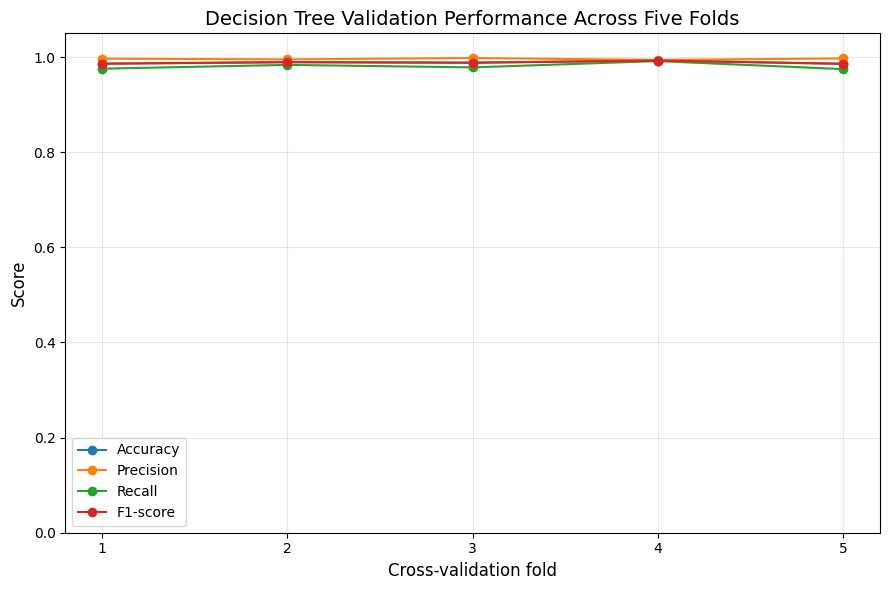

Saved cross-validation fold plot to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree/decision_tree_cv_metrics_by_fold.png


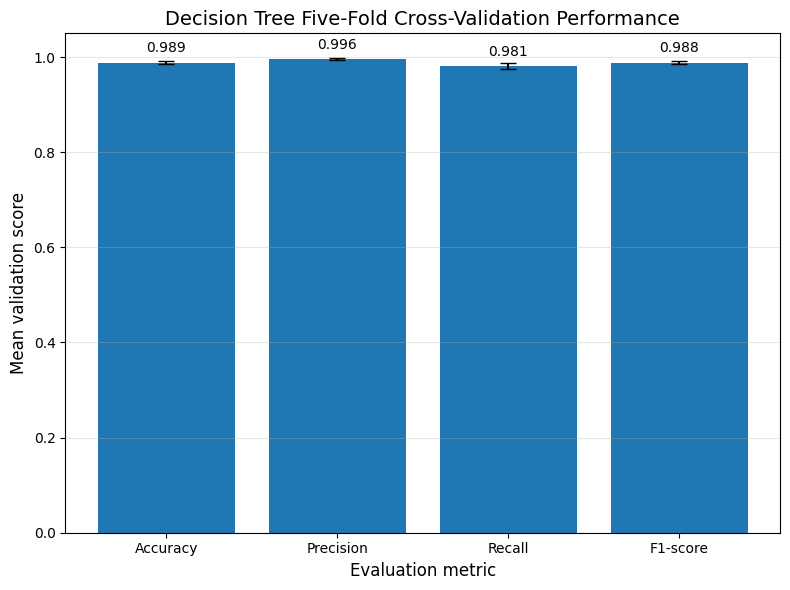

Saved mean cross-validation metric plot to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree/decision_tree_cv_metrics_mean.png


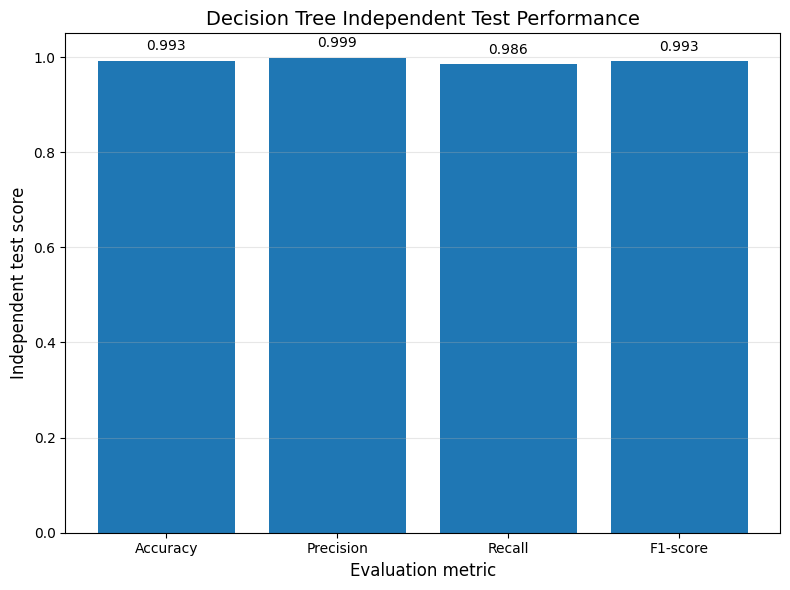

Saved independent test metric plot to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree/decision_tree_independent_test_metrics.png


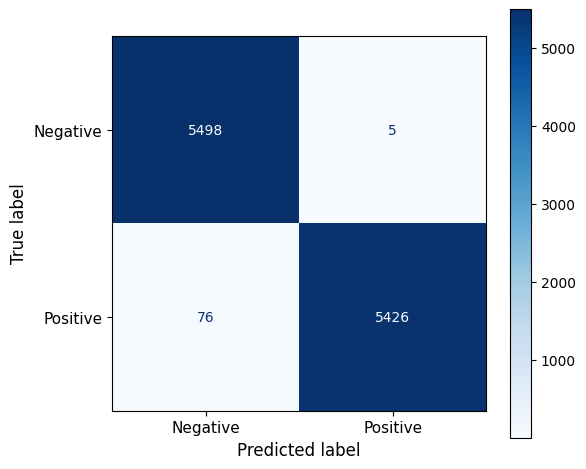

Saved confusion matrix plot to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree/decision_tree_confusion_matrix.png


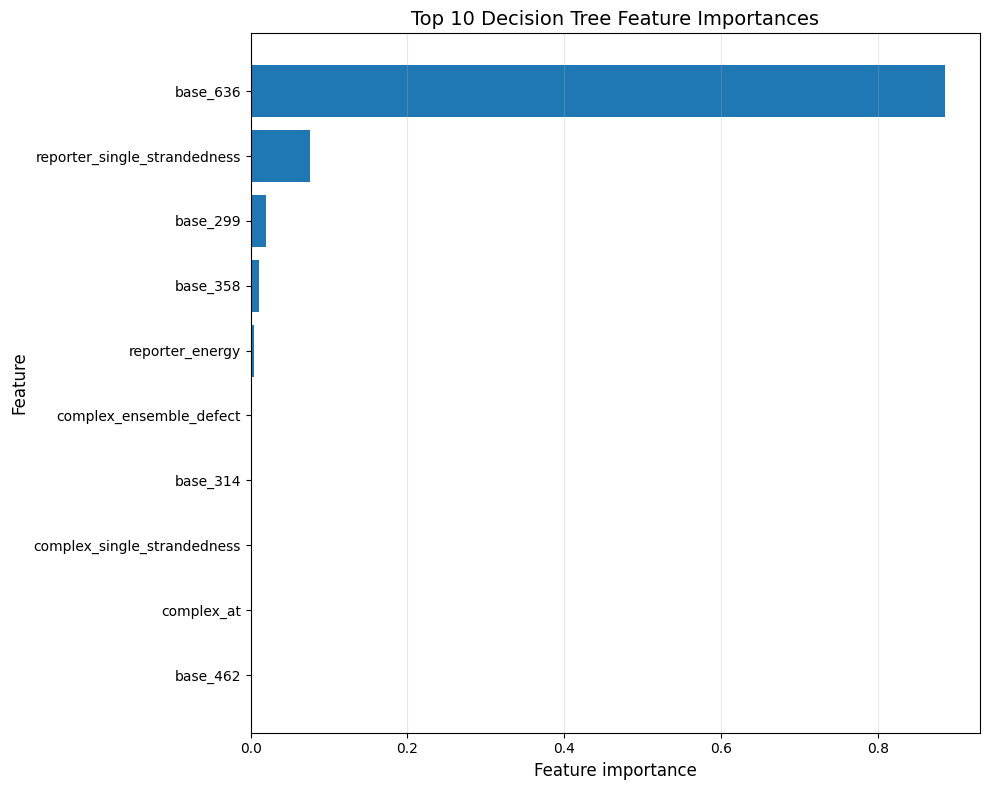

Saved feature-importance plot to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree/decision_tree_feature_importance_top20.png

===== Cross-Validation Results by Fold =====


,fold,val_accuracy,val_precision,val_recall,val_f1
0,1,0.9863,0.9968,0.9757,0.9861
1,2,0.9894,0.9952,0.9836,0.9894
2,3,0.9883,0.9981,0.9784,0.9882
3,4,0.9928,0.9941,0.9916,0.9928
4,5,0.9860,0.9972,0.9748,0.9859



===== Independent Test Results =====


,test_accuracy,test_precision,test_recall,test_f1,true_negative,false_positive,false_negative,true_positive,tree_depth,number_of_leaves
0,0.9926,0.9991,0.9862,0.9926,5498,5,76,5426,10,39



===== Top 10 Features =====


,feature,importance
0,base_636,0.886145
1,reporter_single_strandedness,0.076045
2,base_299,0.019541
3,base_358,0.010090
4,reporter_energy,0.004521
5,complex_ensemble_defect,0.001587
6,base_314,0.000772
7,complex_single_strandedness,0.000227
8,complex_at,0.000128
9,base_462,0.000110



All Decision Tree plots were generated and saved to:
/content/drive/MyDrive/riboMoE_outputs/decision_tree


In [8]:
# Decision Tree Model Evaluation: Visualization and Reporting
#
# This script loads the outputs produced during training and
# evaluation of the riboMoE Decision Tree classifier and
# generates the summary figures used for performance reporting:
#   1. Validation metrics across cross-validation folds
#   2. Mean (+/- SD) cross-validation performance
#   3. Independent test set performance
#   4. Confusion matrix on the independent test set
#   5. Top 20 most important features
#
# All figures are saved as 300 DPI PNGs alongside the model
# outputs, and summary tables are printed for inspection.

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay

OUTPUT_DIR = "/content/drive/MyDrive/riboMoE_outputs/decision_tree"

CV_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "decision_tree_cv_fold_results.csv"
)

TEST_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "decision_tree_independent_test_results.csv"
)

CONFUSION_MATRIX_PATH = os.path.join(
    OUTPUT_DIR,
    "decision_tree_test_confusion_matrix.npy"
)

FEATURE_IMPORTANCE_PATH = os.path.join(
    OUTPUT_DIR,
    "decision_tree_feature_importance.csv"
)

# Confirm that all upstream artifacts exist before proceeding,
# so that a missing file fails fast with a clear message rather
# than surfacing as a cryptic error partway through plotting.
required_files = [
    CV_RESULTS_PATH,
    TEST_RESULTS_PATH,
    CONFUSION_MATRIX_PATH,
    FEATURE_IMPORTANCE_PATH
]

missing_files = [
    file_path
    for file_path in required_files
    if not os.path.isfile(file_path)
]

if missing_files:
    raise FileNotFoundError(
        "The following output files could not be found:\n"
        + "\n".join(missing_files)
        + "\n\nRun the Decision Tree training code first."
    )

print("All required Decision Tree output files were found.")

# Load model outputs generated during training/evaluation
cv_results_df = pd.read_csv(
    CV_RESULTS_PATH
)

test_results_df = pd.read_csv(
    TEST_RESULTS_PATH
)

test_confusion_matrix = np.load(
    CONFUSION_MATRIX_PATH
)

feature_importance_df = pd.read_csv(
    FEATURE_IMPORTANCE_PATH
)


# FIGURE 1: Cross-validation performance across individual folds
#
# Plots accuracy, precision, recall, and F1-score for each of
# the five cross-validation folds to visualize consistency
# (or variability) of the model across data splits.

fold_numbers = cv_results_df["fold"]

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fold_numbers,
    cv_results_df["val_accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    fold_numbers,
    cv_results_df["val_precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    fold_numbers,
    cv_results_df["val_recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    fold_numbers,
    cv_results_df["val_f1"],
    marker="o",
    label="F1-score"
)

plt.xlabel(
    "Cross-validation fold",
    fontsize=12
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.title(
    "Decision Tree Validation Performance Across Five Folds",
    fontsize=14
)

plt.xticks(
    fold_numbers
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

cv_fold_plot_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_cv_metrics_by_fold.png"
)

plt.savefig(
    cv_fold_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved cross-validation fold plot to:\n"
    f"{cv_fold_plot_path}"
)


# FIGURE 2: Mean cross-validation performance with error bars
#
# Summarizes the five-fold cross-validation results as a single
# bar chart, with error bars showing the standard deviation
# across folds for each metric. This gives a compact overview
# of both average performance and its stability.

metric_columns = {
    "Accuracy": "val_accuracy",
    "Precision": "val_precision",
    "Recall": "val_recall",
    "F1-score": "val_f1"
}

metric_names = list(
    metric_columns.keys()
)

metric_means = [
    cv_results_df[column].mean()
    for column in metric_columns.values()
]

# Population standard deviation (ddof=0) is used so that the
# error bars reflect the spread observed across the five folds
# actually run, rather than an estimate of a larger population.
metric_standard_deviations = [
    cv_results_df[column].std(ddof=0)
    for column in metric_columns.values()
]

plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    metric_names,
    metric_means,
    yerr=metric_standard_deviations,
    capsize=6
)

plt.xlabel(
    "Evaluation metric",
    fontsize=12
)

plt.ylabel(
    "Mean validation score",
    fontsize=12
)

plt.title(
    "Decision Tree Five-Fold Cross-Validation Performance",
    fontsize=14
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y",
    alpha=0.3
)

# Annotate each bar with its mean value for easy reading
# without needing to consult the underlying table.
for bar, mean_value in zip(
    bars,
    metric_means
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean_value + 0.015,
        f"{mean_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

cv_summary_plot_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_cv_metrics_mean.png"
)

plt.savefig(
    cv_summary_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved mean cross-validation metric plot to:\n"
    f"{cv_summary_plot_path}"
)


# FIGURE 3: Performance on the held-out independent test set
#
# Reports accuracy, precision, recall, and F1-score for the
# final model on data that was not used during training or
# cross-validation, providing an unbiased estimate of
# generalization performance.

test_metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

test_metric_values = [
    test_results_df.loc[0, "test_accuracy"],
    test_results_df.loc[0, "test_precision"],
    test_results_df.loc[0, "test_recall"],
    test_results_df.loc[0, "test_f1"]
]

plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    test_metric_names,
    test_metric_values
)

plt.xlabel(
    "Evaluation metric",
    fontsize=12
)

plt.ylabel(
    "Independent test score",
    fontsize=12
)

plt.title(
    "Decision Tree Independent Test Performance",
    fontsize=14
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, metric_value in zip(
    bars,
    test_metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        metric_value + 0.015,
        f"{metric_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

test_metrics_plot_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_independent_test_metrics.png"
)

plt.savefig(
    test_metrics_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved independent test metric plot to:\n"
    f"{test_metrics_plot_path}"
)


# FIGURE 4: Confusion Matrix on the Independent Test Set
#
# Breaks down predictions into true/false positives and
# negatives, providing a detailed view of classification
# performance on the held-out test set.

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

confusion_matrix_display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_xlabel(
    "Predicted label",
    fontsize=12
)

ax.set_ylabel(
    "True label",
    fontsize=12
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

confusion_matrix_plot_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved confusion matrix plot to:\n"
    f"{confusion_matrix_plot_path}"
)


# FIGURE 5: Top 10 features by importance
#
# Visualizes the relative contribution of the 20 most
# influential features to the trained Decision Tree, ranked
# from most to least important, to aid biological
# interpretation of the model.

top_feature_count = 10

# Features are assumed to arrive pre-sorted in descending order
# of importance; re-sorting in ascending order here ensures the
# most important feature appears at the top of the horizontal
# bar chart (matplotlib plots bottom-to-top by default).
top_features_df = (
    feature_importance_df
    .head(top_feature_count)
    .sort_values(
        by="importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features_df["feature"],
    top_features_df["importance"]
)

plt.xlabel(
    "Feature importance",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    f"Top {top_feature_count} Decision Tree Feature Importances",
    fontsize=14
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

feature_importance_plot_path = os.path.join(
    OUTPUT_DIR,
    "decision_tree_feature_importance_top20.png"
)

plt.savefig(
    feature_importance_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved feature-importance plot to:\n"
    f"{feature_importance_plot_path}"
)


# SUMMARY TABLES
#
# Printed for quick inspection alongside the figures above;
# these mirror the values plotted and can be copied directly
# into supplementary tables for reporting.

print("\n===== Cross-Validation Results by Fold =====")
display(
    cv_results_df[
        [
            "fold",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1"
        ]
    ].round(4)
)

print("\n===== Independent Test Results =====")
display(
    test_results_df[
        [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "true_negative",
            "false_positive",
            "false_negative",
            "true_positive",
            "tree_depth",
            "number_of_leaves"
        ]
    ].round(4)
)

print("\n===== Top 10 Features =====")
display(
    feature_importance_df
    .head(20)
    .round(6)
)

print(
    "\nAll Decision Tree plots were generated and saved to:\n"
    f"{OUTPUT_DIR}"
)